## Small Image Classification Using Convolutional Neural Network (CNN)

In this notebook, we will classify small images cifar10 dataset from tensorflow keras datasets. There are total 10 classes as shown below. We will use CNN for classification

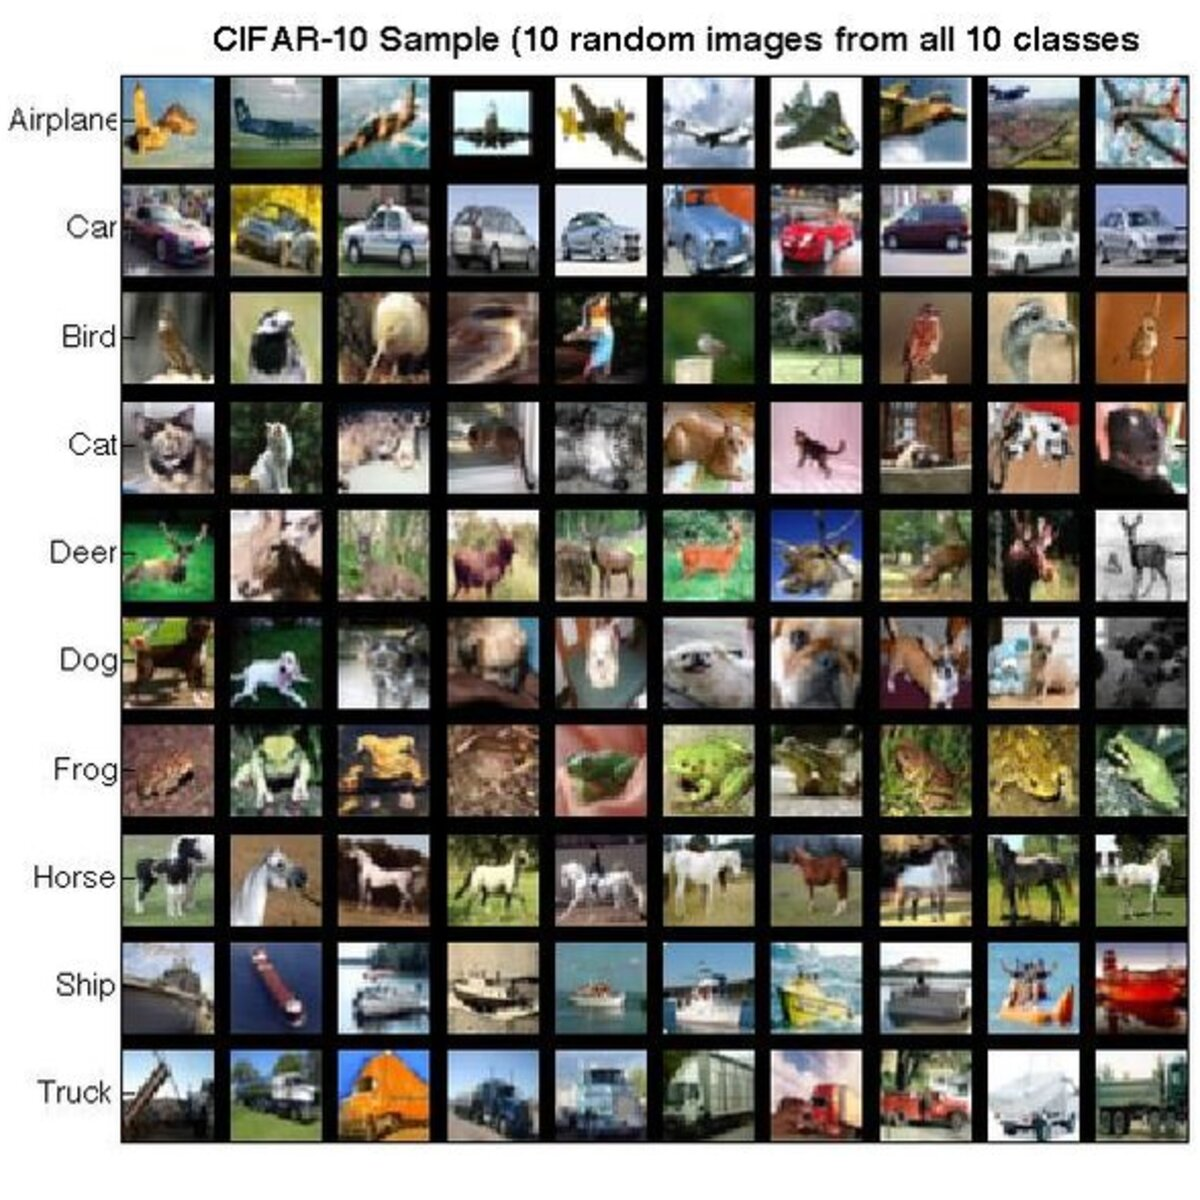

In [1]:
import tensorflow as tf 
from tensorflow.keras import datasets , layers,models 
import matplotlib.pyplot as plt 
import numpy as np

### Load the datset

In [52]:
(X_train , y_train ) , (X_test , y_test) = datasets.cifar10.load_data()


In [53]:
X_train.shape

(50000, 32, 32, 3)

In [54]:
X_test.shape

(10000, 32, 32, 3)

here we see there are 50000 training images and 1000 test images

In [55]:
y_train.shape

(50000, 1)

In [56]:
y_train[:5]

array([[6],
       [9],
       [9],
       [4],
       [1]], dtype=uint8)


y_train is a 2D array, for our classification having 1D array is good enough. so we will convert this to now 1D array

In [57]:
y_train = y_train.reshape(-1,)
y_train[:5]

array([6, 9, 9, 4, 1], dtype=uint8)

In [58]:
y_test = y_test.reshape(-1,)

In [59]:
classes = ["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]

Let's plot some images to see what they are

In [60]:
def plot_sample(X, y, index):
    plt.figure(figsize = (15,2))
    plt.imshow(X[index])
    plt.xlabel(classes[y[index]])

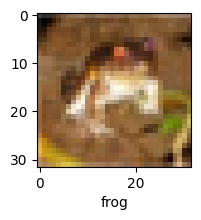

In [61]:
plot_sample(X_train, y_train, 0)

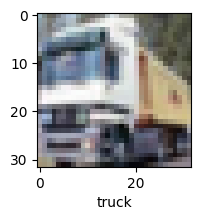

In [62]:
plot_sample(X_train, y_train, 1)

Normalize the images to a number from 0 to 1. Image has 3 channels (R,G,B) and each value in the channel can range from 0 to 255. Hence to normalize in 0-->1 range, we need to divide it by 255

### Normalizing the training data

In [63]:
X_train = X_train / 255.0
X_test = X_test / 255.0

### Build simple artificial neural network for image classification

In [64]:
ann = models.Sequential([
        layers.Flatten(input_shape=(32,32,3)),
        layers.Dense(3000, activation='relu'),
        layers.Dense(1000, activation='relu'),
        layers.Dense(10, activation='softmax')    
    ])

ann.compile(optimizer='SGD',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

ann.fit(X_train, y_train, epochs=5)

c:\Users\singhwins\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 171s 103ms/step - accuracy: 0.3569 - loss: 1.8090
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 171s 110ms/step - accuracy: 0.4294 - loss: 1.6215
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 202s 104ms/step - accuracy: 0.4578 - loss: 1.5392
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 180s 115ms/step - accuracy: 0.4767 - loss: 1.4831
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 181s 116ms/step - accuracy: 0.4962 - loss: 1.4306


#### You can see that at the end of 5 epochs, accuracy is at around 49%

In [65]:
from sklearn.metrics import confusion_matrix , classification_report
import numpy as np 


In [78]:
y_pred = ann.predict(X_test)
y_pred_classes = [np.argmax(element) for element in y_pred]

print("classification report: \n" , classification_report(y_test,y_pred_classes))

313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step
classification report: 
               precision    recall  f1-score   support

           0       0.50      0.60      0.54      1000
           1       0.68      0.40      0.50      1000
           2       0.37      0.41      0.39      1000
           3       0.40      0.21      0.28      1000
           4       0.59      0.15      0.25      1000
           5       0.36      0.44      0.39      1000
           6       0.54      0.52      0.53      1000
           7       0.49      0.60      0.54      1000
           8       0.57      0.63      0.60      1000
           9       0.41      0.72      0.52      1000

    accuracy                           0.47     10000
   macro avg       0.49      0.47      0.45     10000
weighted avg       0.49      0.47      0.45     10000



#### Now let us build a convolution neural networrk to train our images

1. Create the Sequential Model
                     
                    Sequential means layers are added one after another in order.

                    Data flows from first layer → last layer.

2. First Convolution Layer

What it does:

                        Applies 32 filters (kernels) to the image.

                        Each filter size = 3×3.

                        Detects features like:

                        edges

                        lines

                        textures

In [68]:
cnn = models.Sequential([
    layers.Conv2D(filters=32 , kernel_size = (3,3),
                 activation = "relu" , input_shape=(32,32,3)),
      
      layers.MaxPool2D((2,2)),
      
      
      layers.Conv2D(filters=64, kernel_size= (3,3),activation="relu"),
      layers.MaxPooling2D((2,2)),
      
      layers.Flatten(),
      layers.Dense(64,activation = "relu"),
      layers.Dense(10,activation="softmax")
      
])

c:\Users\singhwins\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [69]:
cnn.compile(optimizer= "adam",
            loss = "sparse_categorical_crossentropy",
            metrics = ["accuracy"])

In [70]:
cnn.fit(X_train, y_train, epochs=10)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 93s 50ms/step - accuracy: 0.4666 - loss: 1.4824
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 61s 39ms/step - accuracy: 0.6029 - loss: 1.1332
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 70s 31ms/step - accuracy: 0.6544 - loss: 0.9986
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 86s 34ms/step - accuracy: 0.6855 - loss: 0.9123
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 55s 35ms/step - accuracy: 0.7059 - loss: 0.8489
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 54s 34ms/step - accuracy: 0.7253 - loss: 0.7912
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 58s 37ms/step - accuracy: 0.7411 - loss: 0.7441
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 52s 33ms/step - accuracy: 0.7574 - loss: 0.7000
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 80s 32ms/step - accuracy: 0.7692 - loss: 0.6614
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 32ms/step - accuracy: 0.7811 - loss: 0.6253


With CNN, at the end 5 epochs, accuracy was at around 70% which is a significant improvement over ANN. CNN's are best for image classification and gives superb accuracy. Also computation is much less compared to simple ANN as maxpooling reduces the image dimensions while still preserving the features

In [71]:
cnn.evaluate(X_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.6853 - loss: 0.9640


[0.9640471935272217, 0.6852999925613403]

In [72]:
y_pred = cnn.predict(X_test)
y_pred[:5]

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step


array([[7.0933584e-04, 7.0605078e-05, 2.4632902e-03, 9.0068579e-01,
        8.1791710e-05, 6.7769445e-02, 2.1354286e-02, 1.1905031e-05,
        6.5594241e-03, 2.9413510e-04],
       [4.7567831e-03, 1.1456230e-01, 9.4181914e-06, 3.6524439e-06,
        2.1566650e-06, 2.2019041e-08, 3.1741035e-06, 3.6819343e-09,
        8.7899512e-01, 1.6673786e-03],
       [5.8879666e-02, 1.2526703e-01, 5.7352700e-05, 7.3599638e-03,
        9.1448805e-04, 6.1989954e-04, 1.0953393e-04, 1.4290266e-03,
        7.5035805e-01, 5.5005014e-02],
       [9.6945781e-01, 4.7325031e-03, 6.0223852e-04, 9.2952454e-04,
        1.3862873e-03, 3.0423498e-05, 4.7410429e-03, 6.2640967e-05,
        1.7773435e-02, 2.8400403e-04],
       [2.7348458e-05, 1.2534746e-04, 5.8568628e-03, 7.7313827e-03,
        1.5153453e-01, 3.7923702e-03, 8.3070439e-01, 1.0443355e-05,
        2.0409234e-04, 1.3234514e-05]], dtype=float32)

In [73]:
y_classes = [np.argmax(element) for element in y_pred]
y_classes[:5]

[np.int64(3), np.int64(8), np.int64(8), np.int64(0), np.int64(6)]

In [74]:
y_test[:5]

array([3, 8, 8, 0, 6], dtype=uint8)

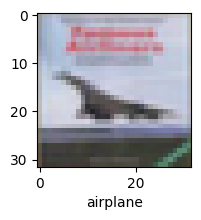

In [75]:
plot_sample(X_test, y_test,3)

In [76]:
classes[y_classes[3]]

'airplane'

In [77]:
classes[y_classes[3]]

'airplane'